# Experimentos paramétricos (E1–E5)

Análisis de sensibilidad a parámetros clave de configuración:
- **E0** - Impacto del ventilador
- **E1** — Impacto de la cuantización (bits por peso)
- **E2** — Impacto del tamaño de contexto
- **E3** — Impacto del batch size (prefill)
- **E4** — Comparación de motores (OLLAMA vs LLAMA)
- **E5** — Aceleración Hailo10h (si disponible)

Cada experimento requiere runs específicos en `data/raw_runs/`.
Las celdas que no tienen datos muestran un mensaje explicativo y
no lanzan ningún error.

In [1]:
"""Configuración e imports."""

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd

from monitorviz.io import load_collection
from monitorviz.viz import sensitivity_curve, setup_style

setup_style("talk")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == "notebooks" else _here
DATA_DIR = PROJECT_ROOT / "data" / "tfg-data"

assert DATA_DIR.is_dir(), f"❌ No encontrado: {DATA_DIR.resolve()}"

coll = load_collection(DATA_DIR)
summary = coll.summary_df()
print(f"Runs cargados: {len(coll)}")
print(f"Modelos: {summary['model_short'].tolist()}")
print(f"\nColumnas de summary_df disponibles:")
print(summary.columns.tolist())

Runs cargados: 120
Modelos: ['ministral:q4_k_m', 'Ministral-3-3B-Instruct-2512-Q4_K_M', 'llama3.2_3b:q4_k_m', 'Llama-3.2-3B-Instruct-Q4_K_M', 'llama3.2_1b:q4_k_m', 'Llama-3.2-1B-Instruct-Q4_K_M', 'granite:q4_k_m', 'granite-4.0-h-micro-Q4_K_M', 'gemma:q4_k_m', 'gemma-4.5B-3n-E2B-it-Q4_K_M', 'deepseek:q4_k_m', 'DeepSeek-R1-Distill-Qwen-1.5B-Q4_K_M', 'ministral:q4_k_m', 'Ministral-3-3B-Instruct-2512-Q4_K_M', 'llama3.2_3b:q4_k_m', 'Llama-3.2-3B-Instruct-Q4_K_M', 'llama3.2_1b:q4_k_m', 'Llama-3.2-1B-Instruct-Q4_K_M', 'granite:q4_k_m', 'granite-4.0-h-micro-Q4_K_M', 'gemma:q4_k_m', 'gemma-4.5B-3n-E2B-it-Q4_K_M', 'deepseek:q4_k_m', 'DeepSeek-R1-Distill-Qwen-1.5B-Q4_K_M', 'ministral:q4_k_m', 'Ministral-3-3B-Instruct-2512-Q4_K_M', 'llama3.2_3b:q4_k_m', 'Llama-3.2-3B-Instruct-Q4_K_M', 'llama3.2_1b:q4_k_m', 'Llama-3.2-1B-Instruct-Q4_K_M', 'granite:q4_k_m', 'granite-4.0-h-micro-Q4_K_M', 'gemma:q4_k_m', 'gemma-4.5B-3n-E2B-it-Q4_K_M', 'deepseek:q4_k_m', 'DeepSeek-R1-Distill-Qwen-1.5B-Q4_K_M', 'ministr

## E1 — Impacto de la cuantización

Se varía el método de cuantización manteniendo constante el resto
(mismo modelo base, context=2048, batch=512, num_prompts=10).

Métricas: throughput, perplejidad y energía por token frente
a bits por peso (BPW).

> **Requisito**: runs con el mismo modelo en distintas cuantizaciones
> (e.g. Q4_0, Q4_K_M, Q5_K_M, Q8_0). El campo `model_info.quantization`
> debe estar disponible en el `resumen.json`.

In [2]:
# E1: añadir bits_per_weight desde model_info si no está como columna directa
if "bits_per_weight" not in summary.columns:
    from monitorviz.transforms.aggregations import _GGUF_BPW
    bpw_list = []
    for r in coll.runs:
        mi = r.summary.model_info
        if mi:
            bpw = mi.get("bits_per_weight") or _GGUF_BPW.get(
                (mi.get("quantization") or "").upper()
            )
        else:
            bpw = None
        bpw_list.append(bpw)
    summary["bits_per_weight"] = bpw_list

e1 = summary.copy()

# Filtrar a un único modelo base si hay varios; candidate siempre definido
candidate = e1["model_short"].value_counts().index[0] if not e1.empty else ""
e1 = e1[e1["model_short"] == candidate] if candidate else e1

e1_ok = (
    not e1.empty
    and "bits_per_weight" in e1.columns
    and e1["bits_per_weight"].notna().any()
    and e1["bits_per_weight"].nunique() >= 2
)

if not e1_ok:
    print("Sin datos de E1 todavía.")
    print("Necesario: runs del mismo modelo con distintas cuantizaciones.")
else:
    fig = sensitivity_curve(
        e1,
        param_col="bits_per_weight",
        metrics=[
            ("tokens_per_s_mean",  "Throughput (tok/s)"),
            ("perplexity_geomean", "Perplejidad (geomedia)"),
            ("energy_per_token_j", "Energía/token (J)"),
        ],
        param_label="Bits por peso (BPW)",
        title=f"E1 — Sensibilidad a la cuantización ({candidate})",
    )
    plt.show()

Sin datos de E1 todavía.
Necesario: runs del mismo modelo con distintas cuantizaciones.


## E2 — Impacto del tamaño de contexto

Variación del `context_size` (512, 1024, 2048, 4096) sobre un único modelo.
El KV cache crece linealmente con el contexto, por lo que el MBU
debería aumentar y el throughput disminuir para contextos largos.

> **Requisito**: varios runs del mismo modelo con distintos `context_size`.

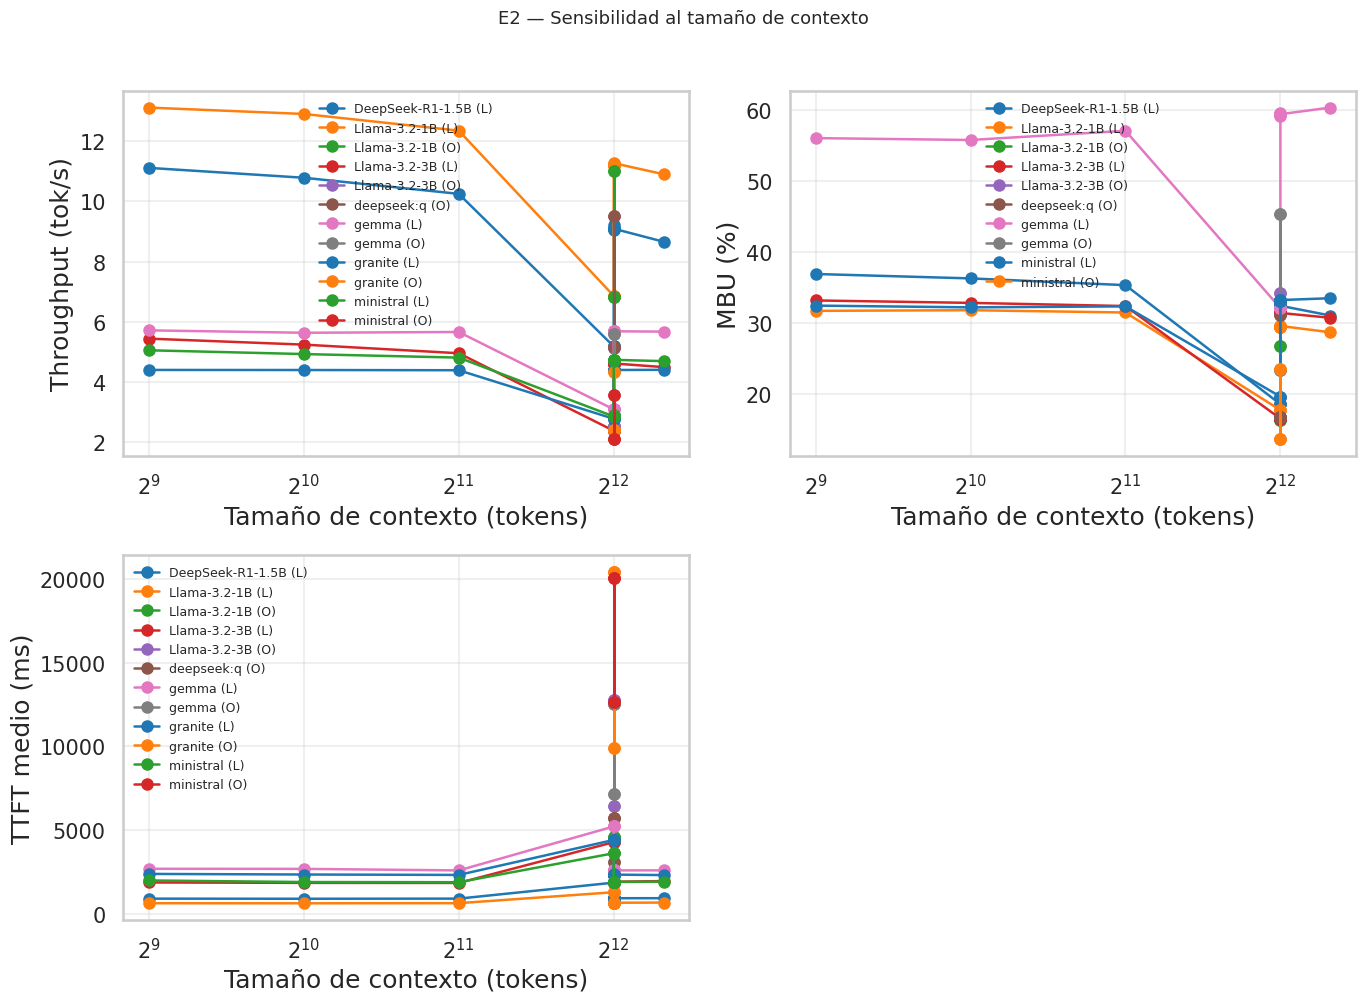

In [3]:
e2 = summary.copy()

e2_ok = (
    not e2.empty
    and "context_size" in e2.columns
    and e2["context_size"].nunique() >= 2
)

if not e2_ok:
    print("Sin datos de E2 todavía.")
    print("Necesario: runs con distintos context_size (512, 1024, 2048, 4096).")
else:
    fig = sensitivity_curve(
        e2,
        param_col="context_size",
        metrics=[
            ("tokens_per_s_mean", "Throughput (tok/s)"),
            ("mbu_pct",           "MBU (%)"),
            ("ttft_ms_mean",      "TTFT medio (ms)"),
        ],
        group_col="model_label",
        param_label="Tamaño de contexto (tokens)",
        log_x=True,
        title="E2 — Sensibilidad al tamaño de contexto",
    )
    plt.show()

## E3 — Impacto del batch size (prefill)

Variación del `batch_size` (128, 256, 512, 1024) sobre un único modelo.
En llama.cpp `n_batch` controla cuántos tokens se procesan en paralelo
durante el prefill. Afecta principalmente al TTFT, no al decode.

> **Requisito**: runs del mismo modelo con distintos `batch_size`.

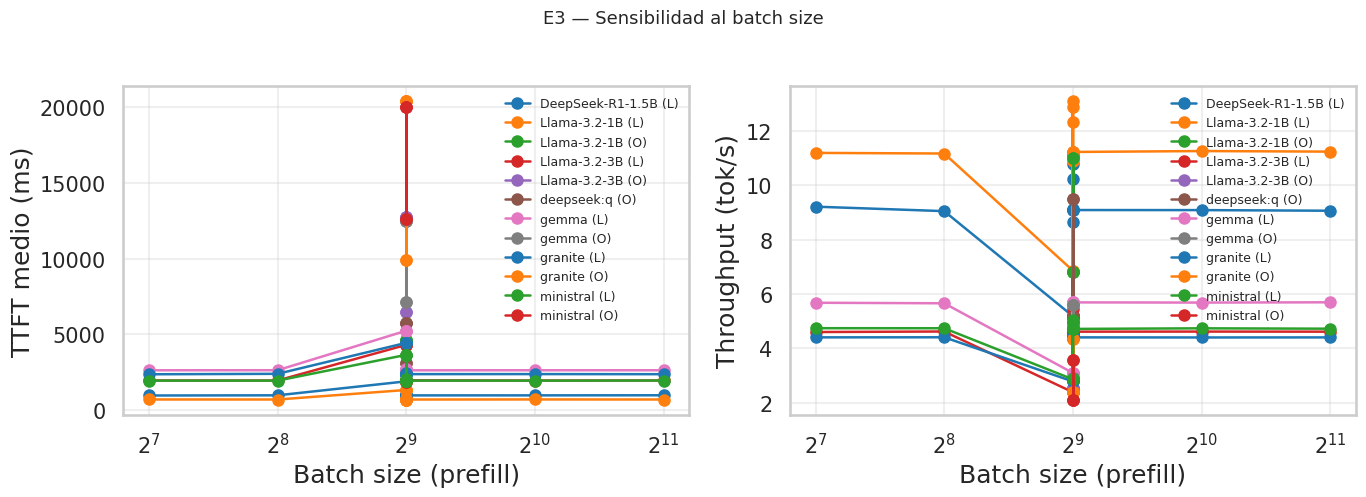

In [4]:
e3 = summary.copy()

e3_ok = (
    not e3.empty
    and "batch_size" in e3.columns
    and e3["batch_size"].nunique() >= 2
)

if not e3_ok:
    print("Sin datos de E3 todavía.")
    print("Necesario: runs con distintos batch_size (128, 256, 512, 1024).")
else:
    fig = sensitivity_curve(
        e3,
        param_col="batch_size",
        metrics=[
            ("ttft_ms_mean",      "TTFT medio (ms)"),
            ("tokens_per_s_mean", "Throughput (tok/s)"),
        ],
        group_col="model_label",
        param_label="Batch size (prefill)",
        log_x=True,
        title="E3 — Sensibilidad al batch size",
    )
    plt.show()

## E4 — Comparación de motores (OLLAMA vs LLAMA)

Mismo modelo y configuración con dos motores distintos.
Métricas: throughput, TTFT, perplejidad y energía por token.

> **Requisito**: runs con `inference_engine` = OLLAMA y LLAMA sobre
> el mismo modelo (mismo fichero GGUF o versión equivalente).

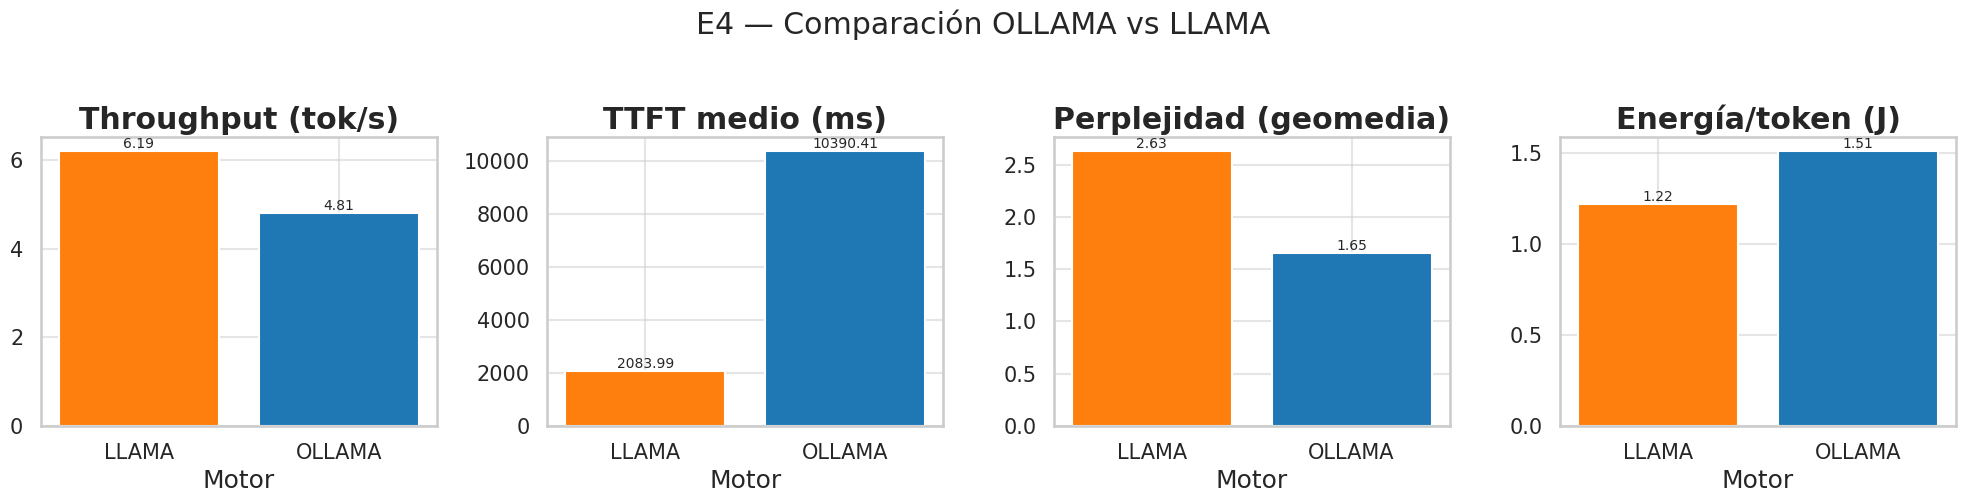

In [5]:
e4 = summary.copy()

e4_ok = (
    not e4.empty
    and "engine" in e4.columns
    and e4["engine"].nunique() >= 2
)

if not e4_ok:
    print("Sin datos de E4 todavía.")
    print("Necesario: runs con engine=OLLAMA y engine=LLAMA sobre el mismo modelo.")
else:
    metrics_e4 = [
        ("tokens_per_s_mean",  "Throughput (tok/s)"),
        ("ttft_ms_mean",       "TTFT medio (ms)"),
        ("perplexity_geomean", "Perplejidad (geomedia)"),
        ("energy_per_token_j", "Energía/token (J)"),
    ]
    n = len(metrics_e4)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    engines = sorted(e4["engine"].unique())
    colors = {"OLLAMA": "tab:blue", "LLAMA": "tab:orange"}
    for ax, (col, label) in zip(axes, metrics_e4):
        if col not in e4.columns:
            ax.set_visible(False)
            continue
        vals = [e4.loc[e4["engine"] == eng, col].mean() for eng in engines]
        bars = ax.bar(engines, vals,
                      color=[colors.get(e, "gray") for e in engines])
        for bar, val in zip(bars, vals):
            ax.annotate(f"{val:.2f}",
                        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                        ha="center", va="bottom", fontsize=10)
        ax.set_title(label)
        ax.set_xlabel("Motor")
    fig.suptitle("E4 — Comparación OLLAMA vs LLAMA", y=1.02)
    fig.tight_layout()
    plt.show()

## E5 — Aceleración Hailo10h

Impacto del acelerador de hardware Hailo10h en throughput y
energía por token, comparado con inferencia en CPU.

> **Requisito**: runs con `accelerator=True` y `accelerator=False`
> sobre el mismo modelo.

In [6]:
e5 = summary.copy()

e5_ok = (
    not e5.empty
    and "accelerator" in e5.columns
    and e5["accelerator"].notna().any()
    and e5["accelerator"].nunique() >= 2
)

if not e5_ok:
    print("Sin datos de E5 todavía.")
    print("Necesario: runs con accelerator=True (Hailo10h) y accelerator=False (CPU).")
else:
    metrics_e5 = [
        ("tokens_per_s_mean",  "Throughput (tok/s)"),
        ("energy_per_token_j", "Energía/token (J)"),
        ("power_mean_w",       "Potencia media (W)"),
    ]
    n = len(metrics_e5)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    labels_map = {True: "Hailo10h", False: "CPU", None: "desconocido"}
    accel_vals = sorted(e5["accelerator"].dropna().unique())
    for ax, (col, ylabel) in zip(axes, metrics_e5):
        if col not in e5.columns:
            ax.set_visible(False)
            continue
        vals = [e5.loc[e5["accelerator"] == a, col].mean() for a in accel_vals]
        xlabels = [labels_map.get(a, str(a)) for a in accel_vals]
        bars = ax.bar(xlabels, vals,
                      color=["tab:green" if a else "tab:gray" for a in accel_vals])
        for bar, val in zip(bars, vals):
            ax.annotate(f"{val:.2f}",
                        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                        ha="center", va="bottom", fontsize=10)
        ax.set_title(ylabel)
    fig.suptitle("E5 — CPU vs Hailo10h", y=1.02)
    fig.tight_layout()
    plt.show()

Sin datos de E5 todavía.
Necesario: runs con accelerator=True (Hailo10h) y accelerator=False (CPU).
